In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
data = np.load("../data/processed/mie_materials_v1.npz", allow_pickle=False)
print(data.files)

['wavelengths_nm', 'material_names', 'materials_n', 'materials_k', 'radius_nm', 'n_medium', 'material_id', 'geometry', 'sigma_sca', 'sigma_abs', 'sigma_ext']


In [3]:
data = np.load("../data/processed/mie_materials_v1.npz", allow_pickle=False)

wl        = data["wavelengths_nm"]   # shape: (N_wl,)
materials = data["material_id"]      # shape: (N_combos,)
radii     = data["radius_nm"]        # shape: (N_combos,)
sigma_sca = data["sigma_sca"]        # shape: (N_combos, N_wl)
sigma_abs = data["sigma_abs"]        # shape: (N_combos, N_wl)

print(f"Wavelengths : {wl.shape}")
print(f"Combos      : {materials.shape}")
print(f"Radii       : {radii.shape}")
print(f"sigma_sca   : {sigma_sca.shape}")
print(f"sigma_abs   : {sigma_abs.shape}")

Wavelengths : (61,)
Combos      : (700,)
Radii       : (700,)
sigma_sca   : (700, 61)
sigma_abs   : (700, 61)


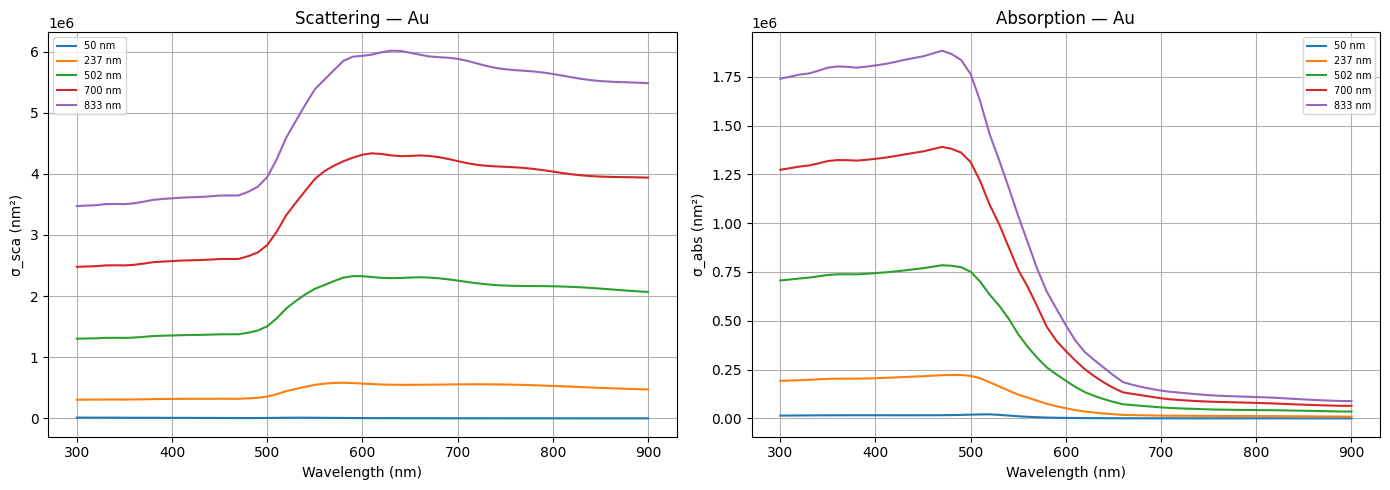

In [4]:
material_name = "Au"
mask = materials == material_name
selected_radii = radii[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx in np.argsort(selected_radii)[::20]:
    axes[0].plot(wl, sigma_sca[mask][idx], label=f"{selected_radii[idx]:.0f} nm")
axes[0].set(xlabel="Wavelength (nm)", ylabel="σ_sca (nm²)", title=f"Scattering — {material_name}")
axes[0].grid(True); axes[0].legend(fontsize=7)

for idx in np.argsort(selected_radii)[::20]:
    axes[1].plot(wl, sigma_abs[mask][idx], label=f"{selected_radii[idx]:.0f} nm")
axes[1].set(xlabel="Wavelength (nm)", ylabel="σ_abs (nm²)", title=f"Absorption — {material_name}")
axes[1].grid(True); axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [5]:
# 1 → peak is defined by scattering maximum
# 0 → peak is defined by absorption maximum
PEAK_MODE = 1

In [6]:
PROMINENCE_FRAC = 0.14

rows = []
for i in range(len(radii)):
    y_sca = sigma_sca[i]
    y_abs = sigma_abs[i]

    if PEAK_MODE == 1:
        # Anchor: scattering peaks
        local_peaks, _ = find_peaks(y_sca, prominence=PROMINENCE_FRAC * y_sca.max())
        global_peak    = int(np.argmax(y_sca))
    else:
        # Anchor: absorption peaks
        local_peaks, _ = find_peaks(y_abs, prominence=PROMINENCE_FRAC * y_abs.max())
        global_peak    = int(np.argmax(y_abs))

    all_peaks = np.unique(np.append(local_peaks, global_peak))

    for p in all_peaks:
        rows.append({
            "combo_idx"    : i,
            "material"     : str(materials[i]),
            "radius_nm"    : float(radii[i]),
            "peak_lambda_nm": float(wl[p]),          # anchor peak wavelength
            "sigma_sca_nm2": float(y_sca[p]),        # sca value AT that lambda
            "sigma_abs_nm2": float(y_abs[p]),        # abs value AT that lambda
            "is_global"    : bool(p == global_peak),
        })

peak_df = pd.DataFrame(rows)
anchor_name = "scattering" if PEAK_MODE == 1 else "absorption"
print(f"Mode          : PEAK_MODE={PEAK_MODE} ({anchor_name}-anchored)")
print(f"Total peaks   : {len(peak_df)}")
print(f"Unique combos : {peak_df['combo_idx'].nunique()}")
peak_df.head()

Mode          : PEAK_MODE=1 (scattering-anchored)
Total peaks   : 979
Unique combos : 700


,combo_idx,material,radius_nm,peak_lambda_nm,sigma_sca_nm2,sigma_abs_nm2,is_global
0,0,Ag,655.113603,430.0,4.235705e+06,105186.047013,True
1,1,Ag,306.297378,390.0,1.104732e+06,60871.795597,True
2,2,Ag,88.924848,380.0,1.509199e+05,15331.701195,True
3,3,Ag,65.701254,430.0,7.933738e+04,2340.288625,True
4,4,Ag,822.606727,450.0,6.359938e+06,128878.528029,True


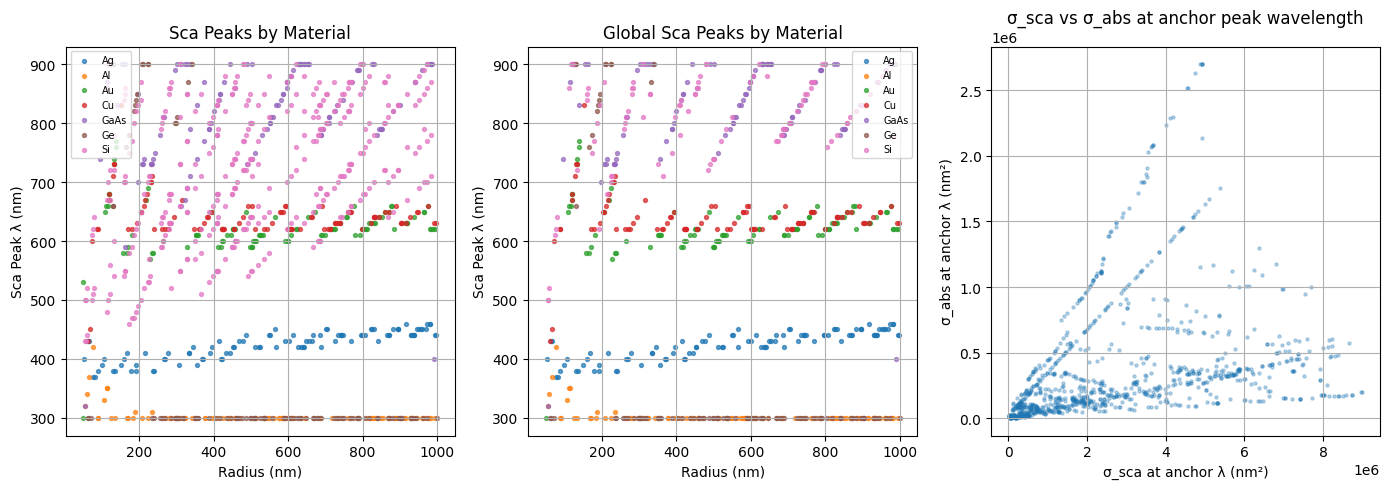

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

global_df = peak_df
for mat in global_df["material"].unique():
    sub = global_df[global_df["material"] == mat]
    axes[0].scatter(sub["radius_nm"], sub["peak_lambda_nm"], s=8, label=mat, alpha=0.7)
axes[0].set(xlabel="Radius (nm)", ylabel=f"{'Sca' if PEAK_MODE else 'Abs'} Peak λ (nm)",
            title=f"{'Sca' if PEAK_MODE else 'Abs'} Peaks by Material")
axes[0].legend(fontsize=7); axes[0].grid(True)

global_df = peak_df[peak_df["is_global"]]
for mat in global_df["material"].unique():
    sub = global_df[global_df["material"] == mat]
    axes[1].scatter(sub["radius_nm"], sub["peak_lambda_nm"], s=8, label=mat, alpha=0.7)
axes[1].set(xlabel="Radius (nm)", ylabel=f"{'Sca' if PEAK_MODE else 'Abs'} Peak λ (nm)",
            title=f"Global {'Sca' if PEAK_MODE else 'Abs'} Peaks by Material")
axes[1].legend(fontsize=7); axes[0].grid(True)
axes[1].grid(True)

axes[2].scatter(peak_df["sigma_sca_nm2"], peak_df["sigma_abs_nm2"], s=5, alpha=0.3)
axes[2].set(xlabel="σ_sca at anchor λ (nm²)", ylabel="σ_abs at anchor λ (nm²)",
            title="σ_sca vs σ_abs at anchor peak wavelength")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [8]:
TARGET_PEAK_WL    = 648       # nm   — desired anchor peak wavelength
TARGET_SCA_SIGMA  = 771_369   # nm²  — desired σ_sca at that wavelength
TARGET_ABS_SIGMA  = 500_000   # nm²  — desired σ_abs at that wavelength

W_PEAK_WL  = 0.50   # anchor wavelength — highest weight
W_SCA_SIG  = 0.25   # scattering amplitude
W_ABS_SIG  = 0.25   # absorption amplitude

assert abs(W_PEAK_WL + W_SCA_SIG + W_ABS_SIG - 1.0) < 1e-9, "Weights must sum to 1"

# Candidate filter
MARGIN_NM = 30

material_summary = peak_df.groupby("material").agg(
    lambda_min=("peak_lambda_nm", "min"),
    lambda_max=("peak_lambda_nm", "max"),
)
candidate_materials = material_summary[
    (material_summary["lambda_min"] <= TARGET_PEAK_WL + MARGIN_NM) &
    (material_summary["lambda_max"] >= TARGET_PEAK_WL - MARGIN_NM)
].index.tolist()

print(f"PEAK_MODE        : {PEAK_MODE}  ({'sca' if PEAK_MODE else 'abs'}-anchored)")
print(f"Target peak λ    : {TARGET_PEAK_WL} nm  ±{MARGIN_NM} nm margin")
print(f"Target σ_sca     : {TARGET_SCA_SIGMA} nm²")
print(f"Target σ_abs     : {TARGET_ABS_SIGMA} nm²")
print(f"Candidate materials ({len(candidate_materials)}): {candidate_materials}")

cand_df = peak_df[peak_df["material"].isin(candidate_materials)].copy()
print(f"Candidate rows: {len(cand_df)}  |  Unique combos: {cand_df['combo_idx'].nunique()}")

PEAK_MODE        : 1  (sca-anchored)
Target peak λ    : 648 nm  ±30 nm margin
Target σ_sca     : 771369 nm²
Target σ_abs     : 500000 nm²
Candidate materials (5): ['Au', 'Cu', 'GaAs', 'Ge', 'Si']
Candidate rows: 779  |  Unique combos: 500


In [9]:
# Normalisation scales
WL_SCALE       = cand_df["peak_lambda_nm"].max() - cand_df["peak_lambda_nm"].min()
SCA_SIGMA_SCALE = cand_df["sigma_sca_nm2"].max()
ABS_SIGMA_SCALE = cand_df["sigma_abs_nm2"].max()

def combined_error_3(peak_wl, sca_sig, abs_sig):
    """Weighted normalised 3-component error."""
    e_wl  = abs(peak_wl - TARGET_PEAK_WL)   / (WL_SCALE        + 1e-9)
    e_sca = abs(sca_sig - TARGET_SCA_SIGMA)  / (SCA_SIGMA_SCALE + 1e-9)
    e_abs = abs(abs_sig - TARGET_ABS_SIGMA)  / (ABS_SIGMA_SCALE + 1e-9)
    return W_PEAK_WL * e_wl + W_SCA_SIG * e_sca + W_ABS_SIG * e_abs


def best_peak_for_group(group):
    errs = group.apply(
        lambda r: combined_error_3(
            r["peak_lambda_nm"], r["sigma_sca_nm2"], r["sigma_abs_nm2"]
        ),
        axis=1,
    )
    best = group.loc[errs.idxmin()]
    return pd.Series({
        "peak_nm"        : best["peak_lambda_nm"],
        "sca_sigma_nm2"  : best["sigma_sca_nm2"],
        "abs_sigma_nm2"  : best["sigma_abs_nm2"],
        "combined_error" : errs.min(),
        "wl_err"         : abs(best["peak_lambda_nm"] - TARGET_PEAK_WL),
        "sca_sig_err"    : abs(best["sigma_sca_nm2"]  - TARGET_SCA_SIGMA),
        "abs_sig_err"    : abs(best["sigma_abs_nm2"]  - TARGET_ABS_SIGMA),
        "is_global"      : bool(best["is_global"]),
    })


combo_lookup = (
    cand_df.groupby(["material", "radius_nm"])
    .apply(best_peak_for_group)
    .reset_index()
    .sort_values("combined_error")
    .reset_index(drop=True)
)

print("Best combos (brute-force baseline, 3-objective):")
cols = ["material", "radius_nm", "peak_nm", "sca_sigma_nm2", "abs_sigma_nm2",
        "wl_err", "sca_sig_err", "abs_sig_err", "combined_error"]
print(combo_lookup[cols].head(10).to_string(index=False))

Best combos (brute-force baseline, 3-objective):
material  radius_nm  peak_nm  sca_sigma_nm2  abs_sigma_nm2  wl_err   sca_sig_err   abs_sig_err  combined_error
    GaAs 313.264845    660.0   5.629223e+05  322887.024518    12.0 208446.681652 177112.975482        0.032425
    GaAs 322.430422    670.0   6.038415e+05  339935.621880    22.0 167527.544115 160064.378120        0.037998
      Si 328.115324    650.0   1.087197e+06  163403.048793     2.0 315827.672557 336596.951207        0.041966
      Si 329.645570    650.0   1.053139e+06  148048.688524     2.0 281769.855676 351951.311476        0.042405
      Si 269.375991    650.0   6.324113e+05  100882.438690     2.0 138957.680215 399117.561310        0.042652
      Si 310.496609    660.0   9.177904e+05  157094.493850    12.0 146421.395293 342905.506150        0.045993
      Si 387.855232    650.0   1.194429e+06  148077.897108     2.0 423060.232953 351922.102892        0.046481
      Si 310.044612    660.0   8.993412e+05  137613.772930    1

/tmp/ipykernel_3010/2666949992.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(best_peak_for_group)


In [10]:
class MieEnv:
    """
    3-objective RL environment: minimise combined error in
    (peak_λ, σ_sca, σ_abs) space.

    The anchor peak (sca or abs) is chosen by PEAK_MODE at data-prep time.
    The env itself is mode-agnostic — it only sees the precomputed table.

    State (10-dim, all normalised to [0, 1]):
        [target_peak_wl, target_sca_sig, target_abs_sig, peak_mode,
         mat_idx, radius_idx,
         current_peak_wl, current_sca_sig, current_abs_sig,
         combined_error]

    Actions:
        0 = radius --
        1 = radius ++
        2 = prev material
        3 = next material
        4 = stop

    Reward = old_combined_error - new_combined_error  (positive = improvement)
             + STOP_BONUS / STOP_PENALTY on action=4
    """

    N_ACTIONS      = 5
    STATE_DIM      = 10
    STOP_BONUS     = 50.0
    STOP_PENALTY   = -20.0
    STOP_THRESHOLD = 0.05
    MAX_STEPS      = 100
    RADIUS_STEP    = 1

    def __init__(
        self,
        combo_lookup    : pd.DataFrame,
        peak_mode       : int,          # 1 = sca-anchored, 0 = abs-anchored
        target_peak_wl  : float,
        target_sca_sig  : float,
        target_abs_sig  : float,
        wl_scale        : float,
        sca_sigma_scale : float,
        abs_sigma_scale : float,
        w_peak_wl : float = W_PEAK_WL,
        w_sca_sig : float = W_SCA_SIG,
        w_abs_sig : float = W_ABS_SIG,
    ):
        self.lookup          = combo_lookup.copy()
        self.peak_mode       = float(peak_mode)
        self.target_peak_wl  = target_peak_wl
        self.target_sca_sig  = target_sca_sig
        self.target_abs_sig  = target_abs_sig
        self.wl_scale        = wl_scale
        self.sca_sigma_scale = sca_sigma_scale
        self.abs_sigma_scale = abs_sigma_scale
        self.w_peak_wl = w_peak_wl
        self.w_sca_sig = w_sca_sig
        self.w_abs_sig = w_abs_sig

        self.mat_list = sorted(self.lookup["material"].unique())
        self.n_mats   = len(self.mat_list)

        # Normalisation ranges for state encoding
        self.wl_min      = self.lookup["peak_nm"].min()
        self.wl_max      = self.lookup["peak_nm"].max()
        self.sca_sig_min = self.lookup["sca_sigma_nm2"].min()
        self.sca_sig_max = self.lookup["sca_sigma_nm2"].max()
        self.abs_sig_min = self.lookup["abs_sigma_nm2"].min()
        self.abs_sig_max = self.lookup["abs_sigma_nm2"].max()
        self.err_max     = self.lookup["combined_error"].max()

        self._build_index()

    def _build_index(self):
        self.mat_radii  = {}
        self.peak_table = {}   # (mat, r_idx) → (peak_wl, sca_sig, abs_sig, cerr)

        for mat in self.mat_list:
            sub = self.lookup[self.lookup["material"] == mat].sort_values("radius_nm")
            self.mat_radii[mat] = sub["radius_nm"].tolist()
            for r_idx, row in enumerate(sub.itertuples()):
                self.peak_table[(mat, r_idx)] = (
                    row.peak_nm,
                    row.sca_sigma_nm2,
                    row.abs_sigma_nm2,
                    row.combined_error,
                    row.is_global,
                )

    def _norm(self, val, lo, hi):
        return float(np.clip((val - lo) / (hi - lo + 1e-9), 0.0, 1.0))

    def _get_state(self):
        peak_wl, sca_sig, abs_sig, cerr, _ = self.peak_table[(self.mat, self.r_idx)]
        return np.array([
            self._norm(self.target_peak_wl, self.wl_min,      self.wl_max),
            self._norm(self.target_sca_sig, self.sca_sig_min, self.sca_sig_max),
            self._norm(self.target_abs_sig, self.abs_sig_min, self.abs_sig_max),
            self.peak_mode,                             # already in {0, 1}
            self._norm(self.mat_idx, 0, self.n_mats - 1),
            self._norm(self.r_idx,   0, len(self.mat_radii[self.mat]) - 1),
            self._norm(peak_wl,  self.wl_min,      self.wl_max),
            self._norm(sca_sig,  self.sca_sig_min, self.sca_sig_max),
            self._norm(abs_sig,  self.abs_sig_min, self.abs_sig_max),
            self._norm(cerr,     0,                self.err_max),
        ], dtype=np.float32)

    def reset(self):
        self.mat_idx = random.randrange(self.n_mats)
        self.mat     = self.mat_list[self.mat_idx]
        self.r_idx   = random.randrange(len(self.mat_radii[self.mat]))
        self.steps   = 0
        *_, self.current_error = self.peak_table[(self.mat, self.r_idx)]
        return self._get_state()

    def step(self, action: int):
        self.steps += 1
        old_error = self.current_error
        n_radii   = len(self.mat_radii[self.mat])

        if action == 0:    # radius --
            self.r_idx = max(0, self.r_idx - self.RADIUS_STEP)
        elif action == 1:  # radius ++
            self.r_idx = min(n_radii - 1, self.r_idx + self.RADIUS_STEP)
        elif action == 2:  # prev material
            self.mat_idx = max(0, self.mat_idx - 1)
            self.mat     = self.mat_list[self.mat_idx]
            self.r_idx   = min(self.r_idx, len(self.mat_radii[self.mat]) - 1)
        elif action == 3:  # next material
            self.mat_idx = min(self.n_mats - 1, self.mat_idx + 1)
            self.mat     = self.mat_list[self.mat_idx]
            self.r_idx   = min(self.r_idx, len(self.mat_radii[self.mat]) - 1)
        elif action == 4:  # stop
            bonus = self.STOP_BONUS if old_error < self.STOP_THRESHOLD else self.STOP_PENALTY
            return self._get_state(), bonus, True, self._info()

        *_, self.current_error = self.peak_table[(self.mat, self.r_idx)]
        reward = old_error - self.current_error
        done   = self.steps >= self.MAX_STEPS
        return self._get_state(), reward, done, self._info()

    def _info(self):
        peak_wl, sca_sig, abs_sig, cerr, is_global = self.peak_table[(self.mat, self.r_idx)]
        anchor = "sca" if self.peak_mode == 1.0 else "abs"
        return {
            "material"      : self.mat,
            "radius_nm"     : self.mat_radii[self.mat][self.r_idx],
            "anchor"        : anchor,
            "peak_wl"       : peak_wl,
            "sca_sig"       : sca_sig,
            "abs_sig"       : abs_sig,
            "is_global"     : is_global,
            "wl_err"        : abs(peak_wl  - self.target_peak_wl),
            "sca_sig_err"   : abs(sca_sig  - self.target_sca_sig),
            "abs_sig_err"   : abs(abs_sig  - self.target_abs_sig),
            "combined_error": cerr,
            "steps"         : self.steps,
        }

env = MieEnv(
    combo_lookup, PEAK_MODE,
    TARGET_PEAK_WL, TARGET_SCA_SIGMA, TARGET_ABS_SIGMA,
    WL_SCALE, SCA_SIGMA_SCALE, ABS_SIGMA_SCALE,
)
s = env.reset()
print("State dim    :", s.shape)   # (10,)
print("Initial state:", s)
s2, r, done, info = env.step(1)
print("After action=1 (radius++):", info)

State dim    : (10,)
Initial state: [0.58       0.0906776  0.18383236 1.         1.         0.5151515
 0.53333336 0.20393547 0.11339845 0.12664695]
After action=1 (radius++): {'material': 'Si', 'radius_nm': 485.91754053250384, 'anchor': 'sca', 'peak_wl': 620.0, 'sca_sig': 1702344.6093511719, 'abs_sig': 319231.5379592564, 'is_global': False, 'wl_err': 28.0, 'sca_sig_err': 930975.6093511719, 'abs_sig_err': 180768.46204074362, 'combined_error': 0.06695285092877155, 'steps': 1}


In [11]:
class DQN(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,    hidden), nn.ReLU(),
            nn.Linear(hidden,    n_actions)
        )

    def forward(self, x):
        return self.net(x)


Transition = collections.namedtuple(
    "Transition", ("state", "action", "reward", "next_state", "done")
)

class ReplayBuffer:
    def __init__(self, capacity: int = 20_000):
        self.buf = collections.deque(maxlen=capacity)

    def push(self, *args):
        self.buf.append(Transition(*args))

    def sample(self, batch_size: int):
        return random.sample(self.buf, batch_size)

    def __len__(self):
        return len(self.buf)

In [12]:
EPISODES      = 1000
BATCH_SIZE    = 64
GAMMA         = 0.95
LR            = 5e-4
EPS_START     = 1.0
EPS_END       = 0.05
EPS_DECAY     = 0.995
TARGET_UPDATE = 50
HIDDEN        = 128
BUFFER_CAP    = 20_000
MIN_BUFFER    = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

env = MieEnv(
    combo_lookup, PEAK_MODE,
    TARGET_PEAK_WL, TARGET_SCA_SIGMA, TARGET_ABS_SIGMA,
    WL_SCALE, SCA_SIGMA_SCALE, ABS_SIGMA_SCALE,
)

online_net = DQN(MieEnv.STATE_DIM, MieEnv.N_ACTIONS, HIDDEN).to(device)
target_net = DQN(MieEnv.STATE_DIM, MieEnv.N_ACTIONS, HIDDEN).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

optimizer = optim.Adam(online_net.parameters(), lr=LR)
buffer    = ReplayBuffer(BUFFER_CAP)
loss_fn   = nn.SmoothL1Loss()

epsilon         = EPS_START
episode_rewards = []
episode_errors  = []

for ep in range(1, EPISODES + 1):
    state  = env.reset()
    ep_ret = 0.0

    while True:
        if random.random() < epsilon:
            action = random.randrange(MieEnv.N_ACTIONS)
        else:
            with torch.no_grad():
                t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(online_net(t).argmax(dim=1).item())

        next_state, reward, done, info = env.step(action)
        buffer.push(state, action, reward, next_state, float(done))
        state   = next_state
        ep_ret += reward

        if len(buffer) >= MIN_BUFFER:
            batch = buffer.sample(BATCH_SIZE)
            b     = Transition(*zip(*batch))

            s_b  = torch.tensor(np.array(b.state),      dtype=torch.float32, device=device)
            a_b  = torch.tensor(b.action,               dtype=torch.long,    device=device).unsqueeze(1)
            r_b  = torch.tensor(b.reward,               dtype=torch.float32, device=device).unsqueeze(1)
            ns_b = torch.tensor(np.array(b.next_state), dtype=torch.float32, device=device)
            d_b  = torch.tensor(b.done,                 dtype=torch.float32, device=device).unsqueeze(1)

            q_curr = online_net(s_b).gather(1, a_b)
            with torch.no_grad():
                q_next = target_net(ns_b).max(dim=1, keepdim=True).values
                q_targ = r_b + GAMMA * q_next * (1 - d_b)

            loss = loss_fn(q_curr, q_targ)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(online_net.parameters(), 1.0)
            optimizer.step()

        if done:
            break

    epsilon = max(EPS_END, epsilon * EPS_DECAY)
    if ep % TARGET_UPDATE == 0:
        target_net.load_state_dict(online_net.state_dict())

    episode_rewards.append(ep_ret)
    episode_errors.append(info["combined_error"])

    if ep % 100 == 0:
        avg_r = np.mean(episode_rewards[-100:])
        avg_e = np.mean(episode_errors[-100:])
        print(f"Ep {ep:4d} | eps={epsilon:.3f} | avg_reward={avg_r:7.2f} | avg_combined_error={avg_e:.4f}")

print("Training done.")

Device: cuda
Ep  100 | eps=0.606 | avg_reward=  -0.33 | avg_combined_error=0.2175
Ep  200 | eps=0.367 | avg_reward=  22.40 | avg_combined_error=0.1387
Ep  300 | eps=0.222 | avg_reward=  29.46 | avg_combined_error=0.1384
Ep  400 | eps=0.135 | avg_reward=  36.55 | avg_combined_error=0.1277
Ep  500 | eps=0.082 | avg_reward=  32.05 | avg_combined_error=0.1459
Ep  600 | eps=0.050 | avg_reward=  39.46 | avg_combined_error=0.1230
Ep  700 | eps=0.050 | avg_reward=  40.38 | avg_combined_error=0.1215
Ep  800 | eps=0.050 | avg_reward=  45.12 | avg_combined_error=0.1184
Ep  900 | eps=0.050 | avg_reward=  41.51 | avg_combined_error=0.1099
Ep 1000 | eps=0.050 | avg_reward=  40.86 | avg_combined_error=0.1046
Training done.


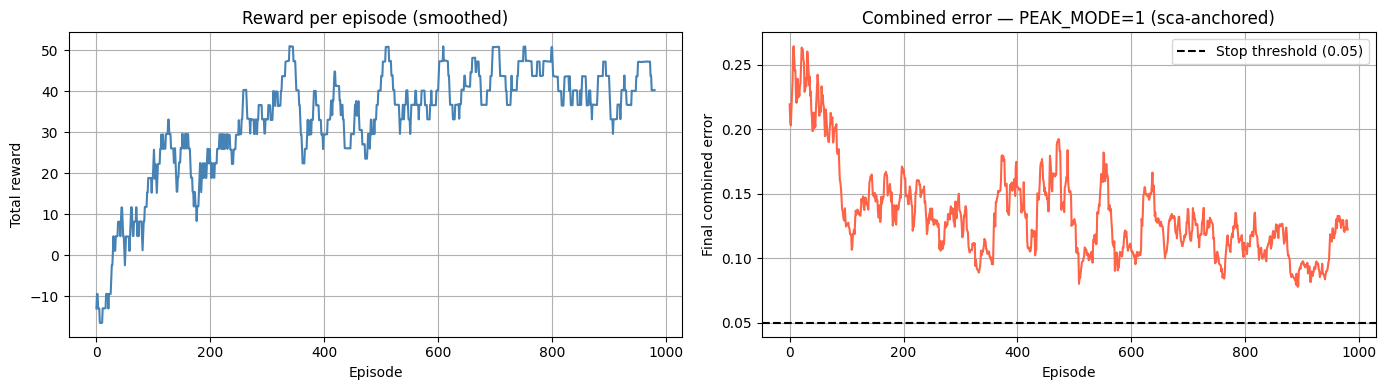

In [13]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(smooth(episode_rewards), color="steelblue")
axes[0].set(xlabel="Episode", ylabel="Total reward", title="Reward per episode (smoothed)")
axes[0].grid(True)

axes[1].plot(smooth(episode_errors), color="tomato")
axes[1].axhline(MieEnv.STOP_THRESHOLD, ls="--", color="k",
                label=f"Stop threshold ({MieEnv.STOP_THRESHOLD:.2f})")
axes[1].set(xlabel="Episode", ylabel="Final combined error",
            title=f"Combined error — PEAK_MODE={PEAK_MODE} ({'sca' if PEAK_MODE else 'abs'}-anchored)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
def run_greedy(env, net, n_trials=200):
    net.eval()
    results = []
    for _ in range(n_trials):
        state = env.reset()
        for _ in range(MieEnv.MAX_STEPS):
            with torch.no_grad():
                t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(net(t).argmax(dim=1).item())
            state, _, done, info = env.step(action)
            if done:
                break
        results.append({
            "material"      : info["material"],
            "radius_nm"     : info["radius_nm"],
            "anchor"        : info["anchor"],
            "peak_wl"       : info["peak_wl"],
            "sca_sig"       : info["sca_sig"],
            "abs_sig"       : info["abs_sig"],
            "is_global"     : info["is_global"],
            "wl_err"        : info["wl_err"],
            "sca_sig_err"   : info["sca_sig_err"],
            "abs_sig_err"   : info["abs_sig_err"],
            "combined_error": info["combined_error"],
            "steps"         : info["steps"],
        })
    return pd.DataFrame(results)


env_eval    = MieEnv(
    combo_lookup, PEAK_MODE,
    TARGET_PEAK_WL, TARGET_SCA_SIGMA, TARGET_ABS_SIGMA,
    WL_SCALE, SCA_SIGMA_SCALE, ABS_SIGMA_SCALE,
)
dqn_results = run_greedy(env_eval, online_net, n_trials=200)
bf_best     = combo_lookup.iloc[0]

anchor_label = "Sca" if PEAK_MODE else "Abs"
print(f"=== Brute-Force Best (PEAK_MODE={PEAK_MODE}, {anchor_label}-anchored) ===")
print(f"  Material       : {bf_best['material']}")
print(f"  Radius         : {bf_best['radius_nm']} nm")
print(f"  Peak λ         : {bf_best['peak_nm']:.2f} nm  (target {TARGET_PEAK_WL} nm, err {bf_best['wl_err']:.2f} nm)")
print(f"  σ_sca at peak  : {bf_best['sca_sigma_nm2']:.0f} nm²  (target {TARGET_SCA_SIGMA} nm²)")
print(f"  σ_abs at peak  : {bf_best['abs_sigma_nm2']:.0f} nm²  (target {TARGET_ABS_SIGMA} nm²)")
print(f"  Combined error : {bf_best['combined_error']:.4f}")
print()
print("=== DQN Agent (200 greedy runs) ===")
print(f"  Mean  combined error : {dqn_results['combined_error'].mean():.4f}")
print(f"  Median combined error: {dqn_results['combined_error'].median():.4f}")
print(f"  Best  combined error : {dqn_results['combined_error'].min():.4f}")
print(f"  Mean  peak λ error   : {dqn_results['wl_err'].mean():.2f} nm")
print(f"  Mean  σ_sca error    : {dqn_results['sca_sig_err'].mean():.0f} nm²")
print(f"  Mean  σ_abs error    : {dqn_results['abs_sig_err'].mean():.0f} nm²")
print(f"  Mean  steps          : {dqn_results['steps'].mean():.1f}")
print(f"  Solved (<{MieEnv.STOP_THRESHOLD}): "
      f"{(dqn_results['combined_error'] < MieEnv.STOP_THRESHOLD).mean()*100:.1f}%")
print(f"  Global peak hits     : {dqn_results['is_global'].mean()*100:.1f}%  "
      f"({dqn_results['is_global'].sum()} / {len(dqn_results)} runs landed on global max)")

=== Brute-Force Best (PEAK_MODE=1, Sca-anchored) ===
  Material       : GaAs
  Radius         : 313.2648449651099 nm
  Peak λ         : 660.00 nm  (target 648 nm, err 12.00 nm)
  σ_sca at peak  : 562922 nm²  (target 771369 nm²)
  σ_abs at peak  : 322887 nm²  (target 500000 nm²)
  Combined error : 0.0324

=== DQN Agent (200 greedy runs) ===
  Mean  combined error : 0.1116
  Median combined error: 0.0935
  Best  combined error : 0.0420
  Mean  peak λ error   : 32.01 nm
  Mean  σ_sca error    : 1852256 nm²
  Mean  σ_abs error    : 340043 nm²
  Mean  steps          : 3.0
  Solved (<0.05): 4.0%
  Global peak hits     : 12.5%  (25 / 200 runs landed on global max)


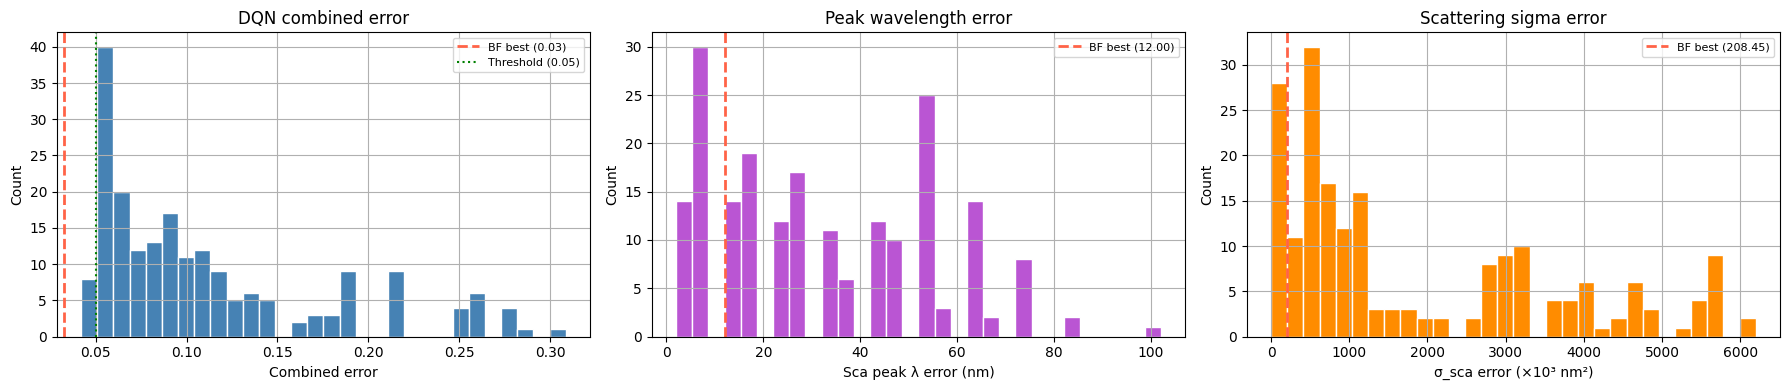

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def plot_err(ax, data, bf_val, xlabel, title, color):
    ax.hist(data, bins=30, color=color, edgecolor="white")
    ax.axvline(bf_val, color="tomato", lw=2, ls="--", label=f"BF best ({bf_val:.2f})")
    ax.set(xlabel=xlabel, ylabel="Count", title=title)
    ax.legend(fontsize=8); ax.grid(True)

plot_err(axes[0], dqn_results["combined_error"],
         bf_best["combined_error"], "Combined error", "DQN combined error", "steelblue")
axes[0].axvline(MieEnv.STOP_THRESHOLD, color="green", lw=1.5, ls=":",
                label=f"Threshold ({MieEnv.STOP_THRESHOLD})")
axes[0].legend(fontsize=8)

plot_err(axes[1], dqn_results["wl_err"],
         bf_best["wl_err"], f"{anchor_label} peak λ error (nm)", "Peak wavelength error", "mediumorchid")

plot_err(axes[2], dqn_results["sca_sig_err"] / 1e3,
         bf_best["sca_sig_err"] / 1e3, "σ_sca error (×10³ nm²)", "Scattering sigma error", "darkorange")

plt.tight_layout()
plt.show()

In [16]:
best_run = dqn_results.loc[dqn_results["combined_error"].idxmin()]
print(f"PEAK_MODE             : {PEAK_MODE}  ({'sca' if PEAK_MODE else 'abs'}-anchored)")
print(f"Target peak λ         : {TARGET_PEAK_WL} nm")
print(f"Target σ_sca          : {TARGET_SCA_SIGMA} nm²")
print(f"Target σ_abs          : {TARGET_ABS_SIGMA} nm²")
print()
print(f"Best DQN material     : {best_run['material']}")
print(f"Best DQN radius       : {best_run['radius_nm']} nm")
print(f"Best peak λ           : {best_run['peak_wl']:.2f} nm  (err {best_run['wl_err']:.2f} nm)")
print(f"Best σ_sca at peak    : {best_run['sca_sig']:.0f} nm²  (err {best_run['sca_sig_err']:.0f} nm²)")
print(f"Best σ_abs at peak    : {best_run['abs_sig']:.0f} nm²  (err {best_run['abs_sig_err']:.0f} nm²)")
print(f"Best combined error   : {best_run['combined_error']:.4f}")
print(f"Steps taken           : {int(best_run['steps'])}")
print(f"Global peak           : {'YES — global maximum' if best_run['is_global'] else 'NO  — local peak'}")

PEAK_MODE             : 1  (sca-anchored)
Target peak λ         : 648 nm
Target σ_sca          : 771369 nm²
Target σ_abs          : 500000 nm²

Best DQN material     : Si
Best DQN radius       : 328.1153241785584 nm
Best peak λ           : 650.00 nm  (err 2.00 nm)
Best σ_sca at peak    : 1087197 nm²  (err 315828 nm²)
Best σ_abs at peak    : 163403 nm²  (err 336597 nm²)
Best combined error   : 0.0420
Steps taken           : 1
Global peak           : NO  — local peak
